# Transaction Category Model Evaluation

This notebook evaluates the classifier implemented in `budget/category_classifier.py` using labeled transactions from the SQLite database.

It reproduces the model pipeline, trains on a train split, and reports metrics on a held-out test split.

## 1) Environment Setup

Run this notebook from the repository root (the folder that contains `manage.py`).

In [10]:
import os
from pathlib import Path

import django


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "manage.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing manage.py")


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "budget_project.settings")
django.setup()

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/jihyung/projects/yn-budget


## 2) Load Labeled Dataset

In [ ]:
import os

import pandas as pd

from budget.category_classifier import TransactionCategoryClassifier

# Jupyter is running with an async event loop, and Django blocks sync DB access unless explicitly allowed
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

classifier = TransactionCategoryClassifier(min_samples=1, min_classes=2)
features, labels = classifier.build_dataset_from_db()

if not features:
    raise ValueError("No labeled transactions found. Add labeled categories in DB first.")

X = pd.DataFrame(features)
y = pd.Series(labels, name="category")

print(f"Rows: {len(X)}")
print(f"Classes: {y.nunique()}")
display(y.value_counts().rename("count").to_frame())

Rows: 1300
Classes: 15


,count
category,
Grocery,478
Eat-outs,262
Travel,113
Household,98
Sport/Health,80
Rent+Utilities,55
Yaki/Nori,47
Home,39
Transportation,39


## 3) Train/Test Split and Model Fit

In [12]:
from sklearn.model_selection import train_test_split

if y.nunique() < 2:
    raise ValueError("Need at least 2 category classes to evaluate classification performance.")

# Stratify only when each class has enough samples for split.
class_counts = y.value_counts()
use_stratify = class_counts.min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if use_stratify else None,
)

model = classifier.create_pipeline()
model.fit(X_train, y_train)

print(f"Train rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Stratified split: {use_stratify}")

Train rows: 1040
Test rows: 260
Stratified split: True


## 4) Metrics

In [13]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8423

Classification report:
                precision    recall  f1-score   support

          Cash       0.00      0.00      0.00         2
      Eat-outs       0.58      0.96      0.72        52
  From Savings       0.00      0.00      0.00         1
       Grocery       0.98      0.84      0.90        95
          Home       0.00      0.00      0.00         8
     Household       1.00      0.75      0.86        20
  Other Income       0.00      0.00      0.00         2
Rent+Utilities       1.00      1.00      1.00        11
       Savings       1.00      1.00      1.00         1
  Sport/Health       1.00      1.00      1.00        16
 Subscriptions       1.00      1.00      1.00         5
Transportation       0.78      0.88      0.82         8
        Travel       1.00      0.78      0.88        23
   Work Income       1.00      1.00      1.00         7
     Yaki/Nori       0.90      1.00      0.95         9

      accuracy                           0.84       260
     

## 5) Confusion Matrix

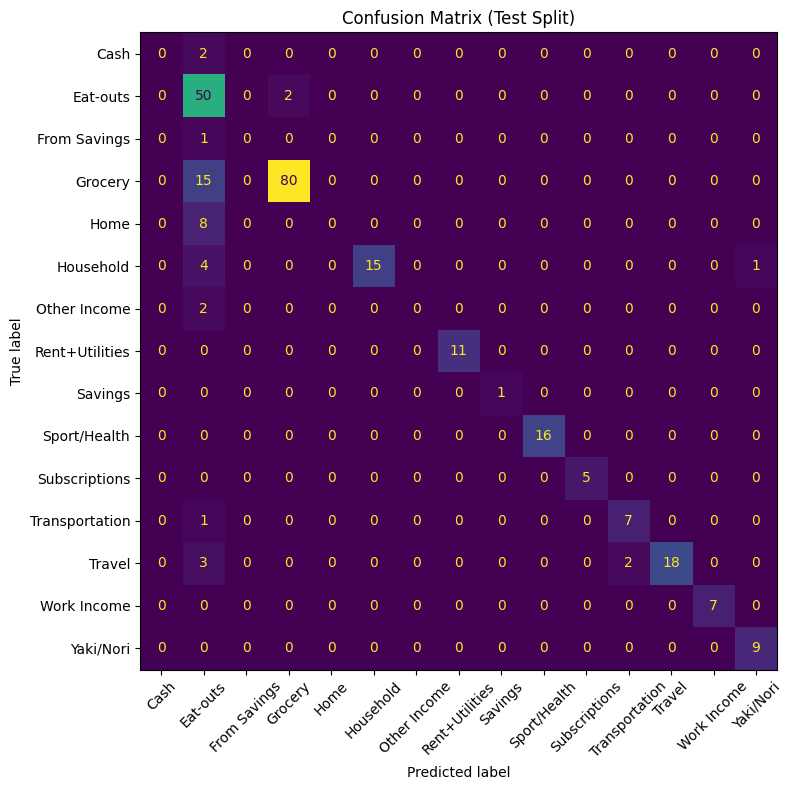

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45,
    ax=ax,
    colorbar=False,
)
ax.set_title("Confusion Matrix (Test Split)")
plt.tight_layout()
plt.show()

## 6) Confidence Threshold Analysis

The production predictor uses a confidence threshold (`min_confidence`, default `0.45`).

This table shows the trade-off between coverage and accuracy at multiple thresholds.

In [15]:
import numpy as np

proba = model.predict_proba(X_test)
best_confidence = proba.max(axis=1)
best_index = proba.argmax(axis=1)
classes = model.named_steps["clf"].classes_
best_prediction = classes[best_index]

threshold_rows = []
for threshold in [0.30, 0.45, 0.60, 0.75]:
    mask = best_confidence >= threshold
    coverage = float(mask.mean())

    if mask.any():
        filtered_accuracy = accuracy_score(y_test[mask], best_prediction[mask])
    else:
        filtered_accuracy = np.nan

    threshold_rows.append(
        {
            "threshold": threshold,
            "coverage": coverage,
            "predicted_rows": int(mask.sum()),
            "accuracy_on_predicted_rows": filtered_accuracy,
        }
    )

display(pd.DataFrame(threshold_rows))

,threshold,coverage,predicted_rows,accuracy_on_predicted_rows
0,0.30,0.911538,237,0.890295
1,0.45,0.692308,180,0.977778
2,0.60,0.607692,158,0.993671
3,0.75,0.480769,125,1.000000
